# Сбор демонстраций для SO-101 в MuJoCo

Этот ноутбук предназначен для сбора демонстраций в среде MuJoCo для задачи: взять кружку и поставить её на тарелку.

Поддерживаются два режима управления:
- **через мастер-руку SO-101** (рекомендуется для воркшопа);
- **с клавиатуры** как запасной вариант.

Сигнал успеха считается полученным, когда кружка оказывается над тарелкой, клешня уже отпущена, а рука поднята вверх.

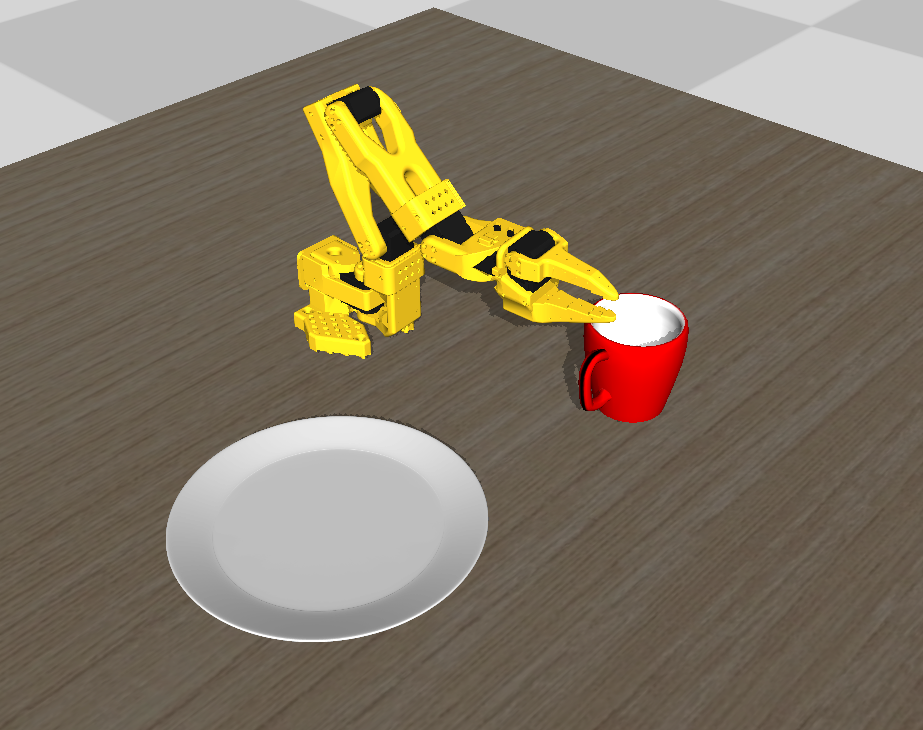

Оверлеи камер во viewer:
- справа сверху — **Agent View**;
- справа снизу — **Top View**;
- слева сверху — **Side View**.

Если используется мастер-рука, управление всеми суставами и клешнёй идёт с неё, а клавиша **Z** в окне MuJoCo делает reset сцены и сбрасывает текущий незавершённый эпизод.


In [1]:
import sys
import random
import numpy as np
import os
import glfw
from PIL import Image
from mujoco_env.y_env import SimpleEnv
from lerobot.common.datasets.lerobot_dataset import LeRobotDataset
from master_arm_control import SO101MasterArmController
import glfw

objc[55289]: Class AVFFrameReceiver is implemented in both /Users/urijstepanov/Documents/LerobotHack/.venv/lib/python3.10/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x10cbd03a8) and /Users/urijstepanov/Documents/LerobotHack/.venv/lib/python3.10/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x12f09c3a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[55289]: Class AVFAudioReceiver is implemented in both /Users/urijstepanov/Documents/LerobotHack/.venv/lib/python3.10/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x10cbd03f8) and /Users/urijstepanov/Documents/LerobotHack/.venv/lib/python3.10/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x12f09c3f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


In [2]:
# Если хочешь каждый раз случайные позиции объектов, поставь SEED = None
SEED = 0
# SEED = None

REPO_NAME = 'so101_pnp'
NUM_DEMO = 1  # количество демонстраций
ROOT = './demo_data'  # папка для сохранения датасета

# Режим управления
USE_MASTER_ARM = False
LEADER_PORT = '/dev/ttyACM0'  # поменяй на свой порт
LEADER_ID = 'leader'          # должен совпадать с id при калибровке leader
MOTION_THRESHOLD = 0.03       # порог, после которого начинаем запись при управлении с мастер-руки


In [3]:
TASK_NAME = 'Поставить кружку на тарелку'
xml_path = './asset/example_scene_y.xml'

# Для мастер-руки удобнее абсолютные углы суставов, для клавиатуры — приращения
action_type = 'joint_angle' if USE_MASTER_ARM else 'delta_joint_angle'

PnPEnv = SimpleEnv(
    xml_path,
    seed=SEED,
    action_type=action_type,
    state_type='joint_angle',
)



-----------------------------------------------------------------------------
name:[Tabletop] dt:[0.002] HZ:[500]
 n_qpos:[20] n_qvel:[18] n_qacc:[18] n_ctrl:[6]
 integrator:[RK4]

n_body:[18]
 [0/18] [world] mass:[0.00]kg
 [1/18] [front_object_table] mass:[1.00]kg
 [2/18] [camera] mass:[0.00]kg
 [3/18] [camera2] mass:[0.00]kg
 [4/18] [camera3] mass:[0.00]kg
 [5/18] [base] mass:[0.15]kg
 [6/18] [shoulder] mass:[0.10]kg
 [7/18] [upper_arm] mass:[0.10]kg
 [8/18] [lower_arm] mass:[0.10]kg
 [9/18] [wrist] mass:[0.08]kg
 [10/18] [gripper] mass:[0.09]kg
 [11/18] [camera_center] mass:[0.00]kg
 [12/18] [tcp_link] mass:[0.01]kg
 [13/18] [moving_jaw_so101_v1] mass:[0.01]kg
 [14/18] [body_obj_mug_5] mass:[0.00]kg
 [15/18] [object_mug_5] mass:[0.08]kg
 [16/18] [body_obj_plate_11] mass:[0.00]kg
 [17/18] [object_plate_11] mass:[0.10]kg
body_total_mass:[1.82]kg

n_geom:[100]
geom_names:['floor', 'front_object_table', None, None, None, None, None, None, None, None, None, None, None, None, None, None,

In [4]:
controller = None

if USE_MASTER_ARM:
    controller = SO101MasterArmController(
        port=LEADER_PORT,
        leader_id=LEADER_ID,
        use_degrees=False,
        motion_threshold=MOTION_THRESHOLD,
    )
    controller.connect()
    print('Мастер-рука подключена')
else:
    print('Используется управление с клавиатуры')


Используется управление с клавиатуры


## Создание датасета LeRobot

Данные сохраняются в формате LeRobot со следующими основными полями:
```
fps = 20
features = {
    "observation.image": {
        "dtype": "image",
        "shape": (256, 256, 3),
    },
    "observation.wrist_image": {
        "dtype": "image",
        "shape": (256, 256, 3),
    },
    "observation.state": {
        "dtype": "float32",
        "shape": (6,),
    },
    "action": {
        "dtype": "float32",
        "shape": (6,),
    },
    "obj_init": {
        "dtype": "float32",
        "shape": (6,),
    },
}
```

После запуска ноутбука датасет будет создан в папке `./demo_data` со структурой вида:

```
.
├── data
│   ├── chunk-000
│   │   ├── episode_000000.parquet
│   │   └── ...
├── meta
│   ├── episodes.jsonl
│   ├── info.json
│   ├── stats.json
│   └── tasks.jsonl
└── images
```


In [5]:
create_new = True
if os.path.exists(ROOT):
    print(f'Папка {ROOT} уже существует.')
    ans = input('Удалить её и создать датасет заново? (y/n) ')
    if ans == 'y':
        import shutil
        shutil.rmtree(ROOT)
    else:
        create_new = False

if create_new:
    dataset = LeRobotDataset.create(
        repo_id=REPO_NAME,
        root=ROOT,
        robot_type='so101',
        fps=20,
        features={
            'observation.image': {
                'dtype': 'image',
                'shape': (256, 256, 3),
                'names': ['height', 'width', 'channels'],
            },
            'observation.wrist_image': {
                'dtype': 'image',
                'shape': (256, 256, 3),
                'names': ['height', 'width', 'channel'],
            },
            'observation.state': {
                'dtype': 'float32',
                'shape': (6,),
                'names': ['state'],
            },
            'action': {
                'dtype': 'float32',
                'shape': (6,),
                'names': ['action'],
            },
            'obj_init': {
                'dtype': 'float32',
                'shape': (6,),
                'names': ['obj_init'],
            },
        },
        image_writer_threads=10,
        image_writer_processes=5,
    )
else:
    print('Загружаю существующий датасет')
    dataset = LeRobotDataset(REPO_NAME, root=ROOT)


Папка ./demo_data уже существует.


## Управление через мастер-руку

В этом ноутбуке основной режим управления — **через мастер-руку SO-101**.

Как это работает:
1. Мастер-рука подключается через отдельный модуль `master_arm_control.py`.
2. Из неё считываются положения суставов и положение клешни.
3. Эти значения сразу передаются в симуляцию как целевые углы follower'а в MuJoCo.

Дополнительно:
- клавиша **Z** в окне MuJoCo делает reset сцены и очищает текущий незавершённый эпизод;
- если `USE_MASTER_ARM = False`, ноутбук автоматически вернётся к управлению с клавиатуры.


## Управление роботом с клавиатуры

### Суставы робота

- **Q / A** — поворот основания (`shoulder_pan`)
- **W / S** — плечо (`shoulder_lift`)
- **E / D** — локоть (`elbow_flex`)
- **I / K** — сгиб кисти (`wrist_flex`)
- **O / L** — вращение кисти (`wrist_roll`)

### Захват

- **SPACE** — открыть / закрыть клешню (`gripper`)

### Сброс сцены

- **Z** — reset сцены и возврат в стартовую позу

### Особенности управления

- Управление работает в режиме **joint-by-joint**
- Каждое нажатие меняет положение одного сустава на небольшой шаг
- Робот удерживает последнее целевое положение суставов
- Все движения ограничены диапазонами SO-101

### Запуск телеоперации и сбор данных

**Чтобы получить сигнал успеха, нужно отпустить клешню и поднять руку выше кружки.**

Если включён режим мастер-руки, запись начинается, когда движение лидера становится заметным.


In [7]:
action = np.zeros(6, dtype=np.float32)
episode_id = 0
record_flag = False
recorded_frames = 0

while PnPEnv.env.is_viewer_alive() and episode_id < NUM_DEMO:
    PnPEnv.step_env()

    if PnPEnv.env.loop_every(HZ=20):
        if USE_MASTER_ARM:
            action = controller.get_action()
            reset = PnPEnv.env.is_key_pressed_once(key=glfw.KEY_Z)
            moved = controller.has_significant_motion(action)
        else:
            action, reset = PnPEnv.teleop_robot()
            moved = np.linalg.norm(action[:-1]) > 1e-6 or abs(float(action[-1])) > 1e-6

        # Сброс сцены с очисткой текущего незавершённого эпизода
        if reset:
            PnPEnv.reset(seed=SEED)
            dataset.clear_episode_buffer()
            record_flag = False
            recorded_frames = 0

            if controller is not None:
                controller.reset_reference()

            print("Сцена сброшена, текущий эпизод очищен")
            continue

        # Если началось движение — начинаем запись
        if not record_flag and moved:
            record_flag = True
            recorded_frames = 0
            print("Начинаю запись")

        # Текущее состояние и изображения
        ee_pose = PnPEnv.get_ee_pose()
        agent_image, wrist_image = PnPEnv.grab_image()

        agent_image = Image.fromarray(agent_image).resize((256, 256))
        wrist_image = Image.fromarray(wrist_image).resize((256, 256))
        agent_image = np.array(agent_image)
        wrist_image = np.array(wrist_image)

        # Применяем действие
        joint_q = PnPEnv.step(action)

        # Если запись активна — добавляем кадр
        if record_flag:
            dataset.add_frame(
                {
                    "observation.image": agent_image,
                    "observation.wrist_image": wrist_image,
                    "observation.state": ee_pose,
                    "action": joint_q,
                    "obj_init": PnPEnv.obj_init_pose,
                    # "task": TASK_NAME,
                },
                task=TASK_NAME,
            )
            recorded_frames += 1

        # Ручное завершение записи по X
        if PnPEnv.env.is_key_pressed_once(key=glfw.KEY_X):
            if record_flag and recorded_frames > 0:
                dataset.save_episode()
                episode_id += 1
                print(f"Эпизод {episode_id} сохранён по кнопке X")
            else:
                dataset.clear_episode_buffer()
                print("Нажата X, но записывать было нечего — эпизод не сохранён")

            PnPEnv.reset(seed=SEED)
            record_flag = False
            recorded_frames = 0

            if controller is not None:
                controller.reset_reference()

            continue

        # Автоматическое завершение по условию успеха
        done = PnPEnv.check_success()
        if done and record_flag and recorded_frames > 0:
            dataset.save_episode()
            episode_id += 1
            print(f"Эпизод {episode_id} сохранён (успех)")

            PnPEnv.reset(seed=SEED)
            record_flag = False
            recorded_frames = 0

            if controller is not None:
                controller.reset_reference()

            continue

        PnPEnv.render(teleop=not USE_MASTER_ARM)

Начинаю запись


Process Process-4:
Process Process-3:
Process Process-1:
Process Process-2:
Process Process-5:
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.10/3.10.20/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/homebrew/Cellar/python@3.10/3.10.20/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/urijstepanov/Documents/LerobotHack/.venv/lib/python3.10/site-packages/lerobot/common/datasets/image_writer.py", line 103, in worker_process
    t.join()
  File "/opt/homebrew/Cellar/python@3.10/3.10.20/Frameworks/Python.framework/Versions/3.10/lib/python3.10/threading.py", line 1096, in join
    self._wait_for_tstate_lock()
  File "/opt/homebrew/Cellar/python@3.10/3.10.20/Frameworks/Python.framework/Versions/3.10/lib/python3.10/threading.py", line 1116, in _wait_for_tstate_lock


KeyboardInterrupt: 

In [8]:
if controller is not None:
    controller.disconnect()

PnPEnv.env.close_viewer()
